In [14]:
# Logging
import logging
logging.basicConfig(level=logging.INFO)

import warnings
warnings.filterwarnings(action='ignore')

# Typing
from typing import Any, Generator, Iterable, Sequence, Optional, Union

# Stdlib
from ast import literal_eval

# I/O
import csv
import json
from pathlib import Path

# Numeric
import pandas as pd
import numpy as np

# Cheminformatics
from rdkit import Chem

# Signac workflow control
import signac
from signac import Project
from signac.job import Job

from flow import FlowProject

# Init.py

## Formatting training data and breaking into jobs

In [15]:
MONO_DATA_DIR = Path('monomer_data_formatted')
# N_TO_SAMPLE : Optional[int] = None
N_TO_SAMPLE : Optional[int] = 12
random : bool = True

mono_data_file_name = 'PolyID_master_data.csv'
mono_data_path = MONO_DATA_DIR / mono_data_file_name
assert(mono_data_path.exists())

READERS_BY_EXT = {
    '.xlsx' : pd.read_excel,
    '.csv'  : pd.read_csv,
}
df_reader_fn = READERS_BY_EXT[mono_data_path.suffix] # don't use get() here; WANT a KeyError if invalid
monomer_df = df_reader_fn(mono_data_path, index_col=0)
monomer_df.replace(np.nan, None, inplace=True) # convert NaN values to JSON-serializable NoneType

if N_TO_SAMPLE is not None:
    if random:
        monomer_df = monomer_df.sample(N_TO_SAMPLE)
    else:
        monomer_df = monomer_df.head(min(N_TO_SAMPLE, len(monomer_df)))
display(monomer_df)

,mechanism<metadata>,smiles_original<metadata>,smiles_canonical<metadata>,smiles_explicit<statedata>,rxn_smarts<statedata>,smiles_polymer_DP2<metadata>,smiles_polymer_DP3<metadata>,smiles_polymer_DP6<metadata>,smiles_polymer_DP18<metadata>,num_monomers<metadata>,...,log10_Permeability_N2<metadata>,log10_Permeability_O2<metadata>,log10_Permeability_H2<metadata>,log10_Permeability_H2O<metadata>,hash-monomers-distribution<metadata>,monomers<metadata>,distribution<metadata>,smiles_polymer<metadata>,hash-smiles_polymer<metadata>,replicate_structure<metadata>
1972,urethane,CC(C)(c1ccc(OCCO)cc1)c1ccc(OCCO)cc1.CP(=O)(c1c...,CC(C)(c1ccc(OCCO)cc1)c1ccc(OCCO)cc1.CP(=O)(c1c...,[H]-[C]1=[C](-[N]=[C]=[O])-[C](-[H])=[C]2-[C](...,[#8:1]=[#6:2]=[#7:3]-[#0:4].[#8:5](-[#0:6])-[H...,None,None,None,None,None,...,None,None,None,None,PY62MXvamXQ4CUZK8uZU4g,"('CC(C)(c1ccc(OCCO)cc1)c1ccc(OCCO)cc1', 'CP(=O...",None,CC(C)(c1ccc(OCCO)cc1)c1ccc(OCCOC(=O)Nc2ccc3c(c...,nD9uZE3kEcokh8BivjLq8L,0.0
1782,imide,O=C(c1ccc2c(c1)C(=O)OC2=O)c1ccc2c(c1)C(=O)OC2=...,Nc1ccc(Oc2ccc(C(c3ccc(Oc4ccc(N)cc4C(F)(F)F)cc3...,[H]-[C]1=[C](-[C](=[O])-[C]2=[C](-[H])-[C](-[H...,[#7:1](-[#0:2])(-[H])-[H].[#0:3]-[#6:4](=[#8:5...,None,None,None,None,None,...,None,None,None,None,groHmpT7Mywk9VAi9uHUW9,('O=C(c1ccc2c(c1)C(=O)OC2=O)c1ccc2c(c1)C(=O)OC...,None,Nc1ccc(Oc2ccc(C(c3ccc(Oc4ccc(N5C(=O)c6ccc(C(=O...,XoEsrDRxKaiXq296nhy6B2,0.0
1741,imide,Cc1cc(Cc2ccc(N)c(C)c2)ccc1N.O=C1OC(=O)c2cc(C(c...,Cc1cc(Cc2ccc(N)c(C)c2)ccc1N.O=C1OC(=O)c2cc(C(c...,[H]-[C]1=[C](-[N](-[H])-[H])-[C](-[C](-[H])(-[...,[#7:1](-[#0:2])(-[H])-[H].[#0:3]-[#6:4](=[#8:5...,None,None,None,None,None,...,-0.314258,0.482159,1.695482,None,erXj7jRF6pYALfwsxXKTq9,"('Cc1cc(Cc2ccc(N)c(C)c2)ccc1N', 'O=C1OC(=O)c2c...",None,Cc1cc(Cc2ccc(N3C(=O)c4ccc(C(c5ccc6c(c5)C(=O)N(...,5UQvxjZubLHbXysNtcWZsJ,0.0
2442,vinyl,FC(F)=C(F)F,FC(F)=C(F)F,[F]-[C](-[F])=[C](-[F])-[F],[#0:1]-[#6:2](-[#0:3])=[#6:4](-[H:5])-[H:6].[#...,None,None,None,None,None,...,0.512008,1.032846,None,1.656841,bK5rbBGK7F6UdkpMAdWLEx,"('FC(F)=C(F)F',)",None,FC(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F...,g9hq7CzpsMEZs9FCayQV3y,0.0
1706,imide,Cc1cc(N)ccc1-c1ccc(N)cc1C.O=C1OC(=O)c2cc(Oc3cc...,Cc1cc(N)ccc1-c1ccc(N)cc1C.O=C1OC(=O)c2cc(Oc3cc...,[H]-[C]1=[C](-[C]2=[C](-[H])-[C](-[H])=[C](-[N...,[#7:1](-[#0:2])(-[H])-[H].[#0:3]-[#6:4](=[#8:5...,None,None,None,None,None,...,None,None,None,None,ce9ciWgH8y4fAcyo2jSSqZ,"('Cc1cc(N)ccc1-c1ccc(N)cc1C', 'O=C1OC(=O)c2cc(...",None,Cc1cc(N)ccc1-c1ccc(N2C(=O)c3ccc(Oc4ccc5c(c4)C(...,EmDtJGGKg6TNK2nfBy4r9J,0.0
1939,NIPU,NCCCCCCN.O=C1OCC(COc2ccc(OCC3COC(=O)O3)cc2)O1,NCCCCCCN.O=C1OCC(COc2ccc(OCC3COC(=O)O3)cc2)O1,[H]-[C]1=[C](-[O]-[C](-[H])(-[H])-[C]2(-[H])-[...,[#0:1]-[#6:2]1(-[H:3])-[#8:4]-[#6:5](=[#8:6])-...,None,None,None,None,None,...,None,None,None,None,hZbwh8NGU6pnFTT8HDwaZG,"('NCCCCCCN', 'O=C1OCC(COc2ccc(OCC3COC(=O)O3)cc...",None,NCCCCCCNC(=O)OC(CO)COc1ccc(OCC(O)COC(=O)NCCCCC...,VFieXYZsh32c62GJo8UXAt,0.0
342,vinyl,C=CC#N.C=CC=C,C=CC#N.C=CC=C,[H]-[C](-[H])=[C](-[H])-[C]#[N].[H]-[C](-[H])=...,[#0:1]-[#6:2](-[#0:3])=[#6:4](-[H:5])-[H:6].[#...,C=CCCCCC#N,C=CCCC(C=C)CC(C)C#N,C=CC(C)CC(C#N)CC(C#N)CC(C=C)CC(C#N)C(C)C#N,C=CC(CCC(C=C)C(C=C)CC(C=C)CC(C#N)CC(C)C#N)CC(C...,2.0,...,None,None,None,None,None,None,None,None,None,None
363,amide,CCCBr.Nc1ccc(C(=O)O)cc1N,CCCBr.Nc1ccc(C(=O)O)cc1N,[H]-[C](-[H])(-[H])-[C](-[H])(-[H])-[C](-[H])(...,[#7:1](-[#0:2])(-[H])-[H:3].[#8](-[#6:4](=[#8:...,None,None,None,None,None,...,-0.853872,-0.075721,1.050766,None,Y4L8ApJh4um28T8A8cQibC,"('CCCBr', 'Nc1ccc(C(=O)O)cc1N')",None,Nc1ccc(C(=O)Nc2ccc(C(=O)Nc3ccc(C(=O)Nc4ccc(C(=...,2yvizpcrxG3FXRUzxmnrht,0.0
1466,imide,CN(C(=O)c1cccc(N)c1)c1ccc(N)cc1.O=C(c1ccc2c(c1...,CN(C(=O)c1cccc(N)c1)c1ccc(N)cc1.O=C(c1ccc2c(c1...,[H]-[C]1=[C](-[C](=[O])-[C]2=[C](-[H])-[C](-[H...,[#7:1](-[#0:2])(-[H])-[H].[#0:3]-[#6:4](=[#8:5...,None,None,None,None,None,...,None,None,None,None,N92XLB9PKtXjPCgZMFCzYr,"('CN(C(=O)c1cccc(N)c1)c1ccc(N)cc1', 'O=C(c1ccc...",None,CN(C(=O)c1cccc(N2C(=O)c3ccc(C(

## Generate jobs for each statepoint, injecting all other parameters not in the dataset

In [16]:
from typing import Any, Generator, Iterable, TypeAlias
StringMap : TypeAlias = dict[str, str]

import re
from itertools import product as cartesian_product


def cartesian_grid(param_options : dict[str, Iterable[Any]]) -> Generator[dict[str, Any], None, None]:
    '''
    Takes a dict keyed by parameter names whose values contain
    possible values for each respective parameter
    
    Exhaustively generates dicts (keyed by the same parameter names) containing every
    unique combination of those parameter values, with exactly one value for each key
    '''
    for param_point in cartesian_product(*param_options.values()):
        yield {
            param_name : param_value
                for param_name, param_value in zip(param_options.keys(), param_point)
        }

def parse_field_names_and_roles(dataframe : pd.DataFrame) -> tuple[StringMap, StringMap]:
    '''Extract the field (column) names and data role metadata
    Returns two dicts mapping from column names as-they-are to names and data roles, respectively'''

    HEADER_ROLE_RE = re.compile('(?P<field_name>.*?)<(?P<field_role>.*?)>') # role is delimited by chevrons

    colname_tag_free  : StringMap = {}
    colname_data_role : StringMap = {}
    for colname in dataframe.columns:
        matches = re.match(HEADER_ROLE_RE, colname)
        assert matches is not None

        match_fields : StringMap = matches.groupdict()
        colname_tag_free[colname] = match_fields['field_name']
        colname_data_role[colname] = match_fields['field_role']
        
    return colname_tag_free, colname_data_role

### Define non-dataset parameters

In [17]:
PARAMS_SWEPT_PATH = Path('parameters_swept.json')
if PARAMS_SWEPT_PATH.exists():
    with PARAMS_SWEPT_PATH.open('r') as file:
        params_swept = json.load(file)
else:
    params_swept = { # define other parameters to sweep here!
        'DOP' : [
            3,
            # 5,
        ],
        'n_atoms_max' : [
            10_000,
            # 20_000,
        ],
        'pcharge_method' : [
            'Espaloma-AM1-BCC',
        ],
    }
    with PARAMS_SWEPT_PATH.open('w') as file:
        json.dump(params_swept, file, indent=4)

In [18]:
PARAMS_SHARED_PATH = Path('parameters_shared.json')
if PARAMS_SHARED_PATH.exists():
    with PARAMS_SHARED_PATH.open('r') as file:
        params_shared = json.load(file)
else:
    params_shared = { # shared default parameters that we don't expect to have to sweep through
        'minimize_oligomer'      : True,
        'forcefield'            : 'openff_unconstrained-2.0.0.offxml', # 'openff-2.0.0.offxml',
        'use_switching_function' : False,
        'switch_width_nm'        : 0.1,
        'nonbonded_cutoff_nm'    : 0.9,
        'box_padding_nm'         : 0.0,
    }
    with PARAMS_SHARED_PATH.open('w') as file:
        json.dump(params_shared, file, indent=4)

In [19]:

from collections import defaultdict

project_path = Path('polyid_test')
project = signac.init_project(project_path)

# populate data into statepoints
field_name, field_role = parse_field_names_and_roles(monomer_df)
for i, row in monomer_df.iterrows():
    # divvy up values according to field role
    rowdata = defaultdict(dict)
    for field, value in row.items():
        rowdata[field_role[field]][field_name[field]] = value

    # generate job statepoints and metadata, inject shared state parameters as needed
    for param_combo in cartesian_grid(params_swept):
        statepoint = {**rowdata['statedata'], **param_combo, **params_shared} # mix together statepoint parameters from all sources
        metadata   = {**rowdata['metadata']} # shunt accessory data from training set to document

        job = project.open_job(statepoint=statepoint)
        job.document = metadata

# Project.py

### Logging - this should live in its own file and eventually be absorbed into polymerist.gentuisl.logutils

In [20]:
from contextlib import contextmanager
from functools import partial


TIMESTAMP_LOG = '%Y-%m-%d %H:%M:%S' # timestamp format to use for logging
LOG_FORMATTER = logging.Formatter('%(asctime)s.%(msecs)03d [%(levelname)-8s:%(module)16s:line %(lineno)-4d] - %(message)s', datefmt=TIMESTAMP_LOG) 

def format_error_for_log(error : Exception) -> str:
    '''Converts a raised Exception to a loggable string'''
    return f'{type(error).__name__}: {error!s}'

def create_file_logger(
        logfile_path : Union[str, Path],
        logger_name : str,
        level : int=logging.INFO,
        mode : str='a',
        formatter : logging.Formatter=LOG_FORMATTER,
        suppress_console_logs : bool=True,
    ) -> tuple[logging.Logger, logging.FileHandler]:
    '''Create a unique logger (bound to a file) for a Signac job'''

    # Create "mouthpiece" proxy logger which will handle log input
    logger = logging.getLogger(logger_name)
    if suppress_console_logs:
        ... # TODO: figure out how to suppress console logs (contextlib.redirect_stdout doesn't work!)

    # Create new handler to target file idempotently, returning a prior equivalent handler if one already exists
    for file_handler in logger.handlers:
        if file_handler.baseFilename == logfile_path:
            file_handler.mode = mode # TOSELF: not sure if this is safe?
            break # stop looking once a handler
    else:
        file_handler = logging.FileHandler(logfile_path, mode=mode) # make new handler if prior handler is not found
        
    # Configure handler properties
    file_handler.setLevel(level)
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

    return logger, file_handler

@contextmanager
def redirect_to_logfile(
        logfile_path : Union[str, Path],
        logger_name : str,
        level : int=logging.INFO,
        mode : str='a',
        formatter : logging.Formatter=LOG_FORMATTER,
        suppress_console_logs : bool=True,
        aux_loggers : Optional[Sequence[logging.Logger]]=None,
    ) -> Generator[logging.Logger, None, None]:
    '''Initializes a to-file logger for a job, and collects logs '''
    # Create a file handler
    proxy_logger, file_handler = create_file_logger(
        logfile_path=logfile_path,
        logger_name=logger_name,
        level=level,
        mode=mode,
        formatter=formatter,
        suppress_console_logs=suppress_console_logs,
    ) 

    # Temporarily bind handler to auxiliary loggers and suppress stdout
    if aux_loggers is None:
        aux_loggers = []

    orig_levels : dict[str, int] = {}
    for aux_logger in aux_loggers:
        orig_levels[aux_logger.name] = aux_logger.getEffectiveLevel() # record initial level for reversion at end
        if suppress_console_logs:
            ... # TODO: figure out how to suppress console logs (contextlib.redirect_stdout doesn't work!)
        aux_logger.addHandler(file_handler)

    # Execute 
    try:
        yield proxy_logger # supply mouthpiece for wrapped context to log to
    except Exception as e:
        proxy_logger.error(format_error_for_log(e))
    finally:
        for aux_logger in aux_loggers:
            aux_logger.setLevel(orig_levels[aux_logger.name])
            aux_logger.removeHandler(file_handler)

### Pre-defining blacklisted atoms and monomers

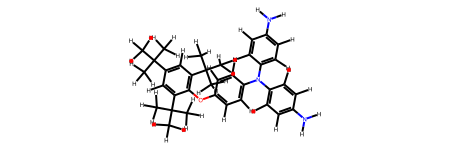

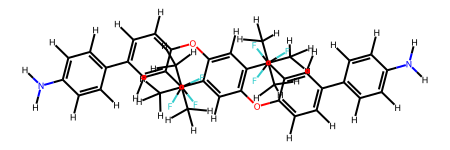

In [21]:
from polymerist.polymers.monomers import specification
from polymerist.smileslib import substructures

# ATOMS, MONOMERS, AND REACTION MECHANISMS WHICH ARE, FOR ONE REASON OR ANOTHER, NOT ALLOWED
BLACKLISTED_ATOM_QUERIES = {
    'silicon' : Chem.MolFromSmarts('[Si]'),
    'sulfur'  : Chem.MolFromSmarts('[S]'),
    'metal'   : substructures.SPECIAL_QUERY_MOLS['metal'],
    # 'halogen' : substructures.SPECIAL_QUERY_MOLS['halogen'],
}

BLACKLISTED_MONOMER_SMILES = [ # monomers which are, for one reason or another, disallowed
    'CC(C)(C)c1cc(c(Oc2ccc(cc2)N(c3ccc(N)cc3)c4ccc(N)cc4)c(c1)C(C)(C)C)C(C)(C)C',  # the extraordinary number of symmetries of this amine ("4-N-(4-aminophenyl)-4-N-[4-(2,4,6-tritert-butylphenoxy)phenyl]benzene-1,4-diamine")... 
    'CC(C)(C)c1cc(Oc2ccc(-c3ccc(N)cc3)cc2C(F)(F)F)c(C(C)(C)C)cc1Oc1ccc(-c2ccc(N)cc2)cc1C(F)(F)F' # ...mean it takes impractically long to isomorphism match during the Topology partition step
] # TODO: might try setting limit of <1000 automorphisms for automatic check (since this is the default limit for substructure matches)
BLACKLISTED_MONOMER_QUERIES = {}
for smiles in BLACKLISTED_MONOMER_SMILES:
    exp_spi = specification.expanded_SMILES(smiles, assign_map_nums=False)
    banned_mol = Chem.MolFromSmiles(exp_spi, sanitize=False)
    display(banned_mol)
    BLACKLISTED_MONOMER_QUERIES[smiles] = banned_mol

BLACKLISTED_MECHANISMS = [
    'imide',
    'vinyl'
]

### Signac project proper

In [22]:
from string import ascii_uppercase
import pickle

# OpenFF toolkits
from openff.toolkit import Molecule, Topology, ForceField
logging.getLogger('openff.toolkit.typing.engines.smirnoff.parameters').setLevel(logging.CRITICAL) # silence annoying Electrostatics up-conversion INFO logs

from openff.units import (
    unit as offunit,
    Unit as OFFUnit,
    Quantity as OFFQuantity,
)
QUANTITY_PRECISION : int = 4 # number of decimal place to report Quanities to when printing/logging

from openff.toolkit.utils.exceptions import (
    MoleculeParseError,
    UnassignedChemistryInPDBError,
    IncorrectNumConformersWarning,
)

# OpenMM imports
from openmm.unit import Quantity as OMMQuantity

# Signac imports
logger_signac = logging.getLogger('signac')
logger_signac_flow = logging.getLogger('signac.flow')
SIGNAC_LOGGERS = [
    logger_signac,
    logger_signac_flow,
]

for logger in SIGNAC_LOGGERS:
    logger.setLevel(logging.INFO)

# Custom (polymerist) imports
import polymerist as ps
from polymerist.genutils.importutils import submodule_loggers
POLYMERIST_LOGGERS = [logger for logger in submodule_loggers(ps).values() if logger is not None]

from polymerist.maths.lattices.integral import CubicIntegerLattice

from polymerist.polymers.monomers import MonomerGroup
from polymerist.polymers.building import build_linear_polymer, mbmol_to_openmm_pdb

from polymerist.mdtools.openfftools import topology, boxvectors
from polymerist.mdtools.openfftools.partition import partition
from polymerist.mdtools.openfftools.partialcharge.molchargers import MolCharger
from polymerist.unitutils.interop import openff_to_openmm, openmm_to_openff

from polymerist.rdutils.rdcoords.tiling import rdmol_effective_radius
from polymerist.rdutils.reactions.reactions import AnnotatedReaction, BadNumberReactants
from polymerist.rdutils.reactions.reactors import PolymerizationReactor

import polybuild_utils


# PROJECT-WIDE FILE NAMES
LOG_FILE_NAME = 'build_logs.log'
FRAG_FILE_NAME = 'fragments.json'
OLIGOMER_PDB_NAME = 'oligomer.pdb'
OLIGOMER_SDF_NAME = 'oligomer.sdf'
MELT_NEAT_SDF_NAME = 'melt_neat.sdf'
MELT_NEAT_INC_NAME = 'melt_neat_interchange.pkl'

def redirect_job_to_logfile(job : Job) -> logging.Logger:
    '''Thin wrapper around redirect_job_to_logfile() which is compatible with Signac jobs'''
    return redirect_to_logfile(
        logfile_path=job.fn(LOG_FILE_NAME),
        logger_name=job.id,
        level=job.project.doc.log_level,
        aux_loggers=POLYMERIST_LOGGERS
    )

# HELPER FUNCTIONS TO LOAD CHEMICAL STRUCTURES FROM STATEPOINT/ACCESORY DATA
def load_job_rdmol(job : Job) -> Chem.Mol:
    '''Helper method for loading an RDKit molecule from the SMILES in a job's statepoint'''
    reactant_mol = Chem.MolFromSmiles(job.sp.smiles_explicit, sanitize=False) # CRITICAL that sanitize=False to avoid stripping
    Chem.SanitizeMol(reactant_mol, sanitizeOps=specification.SANITIZE_AS_KEKULE) # single, unified mol containing individual reactant as disconnected components

    return reactant_mol

def load_job_rxn(job : Job) -> AnnotatedReaction:
    '''Helper method for loading an RDKit molecule from the SMILES in a job's statepoint'''
    rxn = AnnotatedReaction.from_smarts(
        job.sp.rxn_smarts.replace('#0', '*') # NOTE: this is a hack which should be sanitized in the previous rxn assembly step
    )
    rxn.Initialize()
    n_warn, n_err = rxn.Validate()
    # assert n_err == 0

    return rxn

def load_job_topology(job : Job, sdf_pathname : str) -> Optional[Molecule]:
    '''Read and return an OpenFF Topology from well-formed SDF file,
    returning None if encoding or other errors are encountered'''
    if not job.isfile(sdf_pathname):
        return None
    
    with redirect_job_to_logfile(job) as logger:
        sdf_path = Path(job.fn(sdf_pathname))
        if sdf_path.suffix != '.sdf':
            logger.error('Only SDF files are allowed for loading molecules')
            return None

        try:
            return topology.topology_from_sdf(sdf_path)
        except UnassignedChemistryInPDBError: # special cases for known common errors
            logger.error('OpenFF will not load molecule with ambiguous stereochemistry')
            return None
        except MoleculeParseError: # special cases for known common errors
            logger.error('Empty or malformed SDF file, could not read structural data')
            return None

load_job_melt_neat_topology = partial(load_job_topology, sdf_pathname=MELT_NEAT_SDF_NAME)
def load_job_oligomer_molecule(job : Job) -> Optional[Molecule]:
    '''Check whether a topology has atomic partial charges assigned to it'''
    oligomer_top = load_job_topology(job, OLIGOMER_SDF_NAME)
    if oligomer_top is None:
        return None
    return topology.get_largest_offmol(oligomer_top)


# DEFINING THE SIGNAC PROJECT CLASS PROPER 
class PolymerBuildProject(FlowProject):
    pass

# 0) SIMPLE VALIDATION CHECKS ON REACTION DATA
@PolymerBuildProject.label
def atoms_valid(job : Job) -> bool:
    '''Check no banned atom types are present'''
    # 2) check that none of the monomers are blacklisted
    reactant_mol = load_job_rdmol(job)
    return not any(
        substructures.matching_labels_from_substruct_dict(
            reactant_mol,
            BLACKLISTED_ATOM_QUERIES,
        )
    ) # if any illegal atoms are detected in the current monomer, return and exit

@PolymerBuildProject.label
def monomers_allowed(job : Job) -> bool:
    '''Check no banned atom monomer fragments are present'''
    reactant_mol = load_job_rdmol(job)
    return not any(
        substructures.matching_labels_from_substruct_dict(
            reactant_mol,
            BLACKLISTED_MONOMER_QUERIES
        )
    ) # Exclude any monomers which are structurally disallowed

@PolymerBuildProject.label
def mechanism_copied(job : Job) -> bool:
    return 'mechanism' in job.doc

@PolymerBuildProject.label
def mechanism_allowed(job : Job) -> bool:
    '''
    Check that the rxn mechanism type is not explicitly blacklisted
    '''
    return job.doc.mechanism not in BLACKLISTED_MECHANISMS


# 1) TEST FOR RXN TEMPLATE COMPLIANCE AND ENUMERATE CHEMICAL FRAGMENTS
polymerize = PolymerBuildProject.make_group(name='polymerize')

@PolymerBuildProject.label
def reactant_order_evaluated(job : Job) -> bool:
    return 'reactant_ordering' in job.doc

@PolymerBuildProject.label
def matches_rxn_template(job : Job) -> bool:
    return reactant_order_evaluated(job) and (job.doc.reactant_ordering is not None)

@polymerize
@PolymerBuildProject.pre(atoms_valid)
@PolymerBuildProject.pre(monomers_allowed)
@PolymerBuildProject.pre(mechanism_copied)
@PolymerBuildProject.pre(mechanism_allowed)
@PolymerBuildProject.post(reactant_order_evaluated)
@PolymerBuildProject.operation
def determine_reactant_order(job : Job) -> None:
    '''
    Check that SMILES monomers are compatible with the 
    reaction template for the mechanism they claim to follow
    '''
    # 1) check that monomers fit a reaction template
    reactant_mol = load_job_rdmol(job)
    reactants = Chem.GetMolFrags(reactant_mol, asMols=True)
    rxn = load_job_rxn(job)

    with redirect_job_to_logfile(job) as logger:
        try:
            reactant_ordering = rxn.valid_reactant_ordering(reactants, as_mols=False)
            job.doc.reactant_ordering = reactant_ordering # set EVEN if found ordering is None, to indicate this check has already been done
        except BadNumberReactants as bnr_error: # temporarily intercept this error to mark the job as having been checked for post-conditions
            job.doc.reactant_ordering = None
            raise bnr_error # re-raise to propagate this error up to the logger context
        
        if reactant_ordering is not None:
            logger.info(f'Identified valid reactant ordering: {reactant_ordering}')
        else:
            logger.error(f'No valid ordering of reactants could be solved for the chosen "{job.doc.mechanism}" rxn template')

ALLOWED_FUNCTIONALITIES : set[int] = {2}

@PolymerBuildProject.label
def monomers_satisfy_functionality(job : Job) -> bool:
    '''
    Check that all monomers have allowed degrees of functionalization
    '''
    if not matches_rxn_template(job):
        return False
    
    rxn = load_job_rxn(job)
    reactant_smiles_all = job.sp.smiles_explicit.split('.')

    with redirect_job_to_logfile(job) as logger:
        for i in job.doc.reactant_ordering:
            reactant_smiles = reactant_smiles_all[i]
            reactant_mol = Chem.MolFromSmiles(reactant_smiles, sanitize=False) # CRITICAL that sanitize=False to avoid stripping
            Chem.SanitizeMol(reactant_mol, sanitizeOps=specification.SANITIZE_AS_KEKULE) # single, unified mol containing individual reactant as disconnected components
            
            num_funct_groups = substructures.num_substruct_queries_distinct(reactant_mol, rxn.GetReactantTemplate(i))
            if num_funct_groups not in ALLOWED_FUNCTIONALITIES:
                logger.error(f'Found {num_funct_groups} active functional groups (vs any from {ALLOWED_FUNCTIONALITIES}) for molecule {reactant_smiles}')
                return False
        else:
            return True
    
@polymerize
@PolymerBuildProject.pre(matches_rxn_template)
@PolymerBuildProject.pre(monomers_satisfy_functionality)
@PolymerBuildProject.post.isfile(FRAG_FILE_NAME)
@PolymerBuildProject.operation
def enum_fragments(job : Job) -> None:
    '''Enumerate all possible repeat unit fragment using cheminformatic reaction procedure'''
    rxn = load_job_rxn(job)
    reactor = PolymerizationReactor(rxn)

    reactant_mol = load_job_rdmol(job)
    reactants = Chem.GetMolFrags(reactant_mol, asMols=True)

    monogrp = MonomerGroup()
    with redirect_job_to_logfile(job) as logger:
        for intermediates, frags in reactor.propagate(reactants):
            for assoc_group_name, rdfragment in zip(ascii_uppercase, frags):
                # generate spec-compliant SMARTS
                raw_smiles = Chem.MolToSmiles(rdfragment)
                exp_smiles = specification.expanded_SMILES(raw_smiles)
                spec_smarts = specification.compliant_mol_SMARTS(exp_smiles)

                # record to monomer group
                affix = 'TERM' if MonomerGroup.is_terminal(rdfragment) else 'MID'
                monogrp.monomers[f'{assoc_group_name}_{affix}'] = [spec_smarts]

        monogrp.to_file(job.fn(FRAG_FILE_NAME))
        logger.info('Successfully enumerated and cached repeat unit fragments')


# 2) BUILD POLYMER STRUCTURE
oligomerize = PolymerBuildProject.make_group(name='oligomerize')

@oligomerize
@PolymerBuildProject.pre.copy_from(determine_reactant_order)
@PolymerBuildProject.pre.copy_from(enum_fragments)
@PolymerBuildProject.pre.isfile(FRAG_FILE_NAME)
@PolymerBuildProject.post.isfile(OLIGOMER_PDB_NAME)
@PolymerBuildProject.operation
def build_oligomer_pdb(job : Job) -> None:
    '''Generate coordinates and build oligomer PDB file using mBuild'''
    seq = 'BA' # hard-coded for now, plan to make more flexible in the future
    monogrp = MonomerGroup.from_file(job.fn(FRAG_FILE_NAME))
    with redirect_job_to_logfile(job) as logger:
        # check for identical parallel oligomer jobs
        parallel_struct_jobs = project.find_jobs({
            f'sp.{attr}' : getattr(job.sp, attr)
                for attr in ('DOP', 'smiles_explicit')
        })
        for parallel_job in parallel_struct_jobs:
            if (parallel_job.id != job.id) and (parallel_job.isfile(OLIGOMER_PDB_NAME)):
                logger.info(f'Job {parallel_job.id} already has my oligomer PDB!')
                break

        # generate coordinates with mBuild hook
        polymer = build_linear_polymer(
            monomers=monogrp,
            DOP=2*(1 + (job.sp.DOP - 1)/len(seq)), # formula to convert target DOP (considering an AB pair as a repeat unit) to effective DOP in builder
            sequence=seq,
            energy_minimize=True, # TODO: add master config option for energy minimization at project level
        )
        mbmol_to_openmm_pdb(job.fn(OLIGOMER_PDB_NAME), polymer)
        logger.info('Successfully generated PDB structure file')


@PolymerBuildProject.label
def matches_m2p_smiles(job : Job) -> bool:
    '''Check whether the resulting polymer agrees with the SMILES output of M2P (if data is provided)'''
    ...

@PolymerBuildProject.label
def no_ring_piercing(job : Job) -> bool:
    ... # TODO: implement post-minimization bond length check

@PolymerBuildProject.label
def chemical_info_assigned(job : Job) -> bool:
    '''Check whether a topology has atomic partial charges assigned to it'''
    return job.isfile(OLIGOMER_SDF_NAME) and (load_job_oligomer_molecule(job) is not None)

@oligomerize
@PolymerBuildProject.pre.copy_from(build_oligomer_pdb)
@PolymerBuildProject.pre.isfile(OLIGOMER_PDB_NAME)
@PolymerBuildProject.post.isfile(OLIGOMER_SDF_NAME)
@PolymerBuildProject.operation
def assign_chem_info(job : Job) -> None:
    '''Assign chemical information to bare PDB graph and export completely-specified system to SDF file'''
    monogrp = MonomerGroup.from_file(job.fn(FRAG_FILE_NAME))
    with redirect_job_to_logfile(job) as logger:
        offtop = Topology.from_pdb(job.fn(OLIGOMER_PDB_NAME), _custom_substructures=monogrp.monomers)
        if not partition(offtop):
            logger.error(f'Failed to produce residue partition with fragments for job {job.id}')
            return None # exit before writing SDF; will cause post-condition to not be meet
        topology.topology_to_sdf(job.fn(OLIGOMER_SDF_NAME), offtop)
        logger.info('Successfully generated chemically-explicit SDF structure file')

@oligomerize
@PolymerBuildProject.pre(chemical_info_assigned)
@PolymerBuildProject.post.true('r_eff') # this ought to be fine, as these values should never be Falsy
@PolymerBuildProject.post.true('n_atoms_oligomer') # this ought to be fine, as these values should never be Falsy
@PolymerBuildProject.post.true('elem_counts_oligomer') # this ought to be fine, as these values should never be Falsy
@PolymerBuildProject.operation
def summarize_oligomer(job : Job) -> None:
    '''Compute simple summarizing info about an oligomer which streamline lattice packing,
    namely the number of atoms, the distribution of elementsm and the effect (max) radius'''
    offmol = load_job_oligomer_molecule(job)
    job.doc.r_eff = rdmol_effective_radius(offmol.to_rdkit()) # TODO: this shouldn't require an RDKit conversion, just access tot he conformer
    job.doc.n_atoms_oligomer = offmol.n_atoms
    job.doc.elem_counts_oligomer = polybuild_utils.elem_counts(offmol)

@PolymerBuildProject.label
def partial_charges_assigned(job : Job) -> bool:
    '''Check whether a topology has atomic partial charges assigned to it'''
    offmol = load_job_oligomer_molecule(job)
    if offmol is None:
        return False
    
    return offmol.partial_charges is not None
    
@oligomerize
@PolymerBuildProject.pre(chemical_info_assigned)
@PolymerBuildProject.post(partial_charges_assigned) # TODO: fill this in with something more substantive!!
@PolymerBuildProject.operation
def assign_partial_charges(job : Job) -> None:
    '''Generate coordinates and build oligomer PDB file using mBuild'''
    offmol = load_job_oligomer_molecule(job)
    charger_type = MolCharger.subclass_registry.get(job.sp.pcharge_method, None)
    if charger_type is None:
        return
        
    with redirect_job_to_logfile(job) as logger:
        charger = charger_type()
        cmol = charger.charge_molecule(offmol)
        topology.topology_to_sdf(job.fn(OLIGOMER_SDF_NAME), cmol.to_topology())


# 3) PACK LATTICE
pack_lattice = PolymerBuildProject.make_group(name='pack_lattice') 

@PolymerBuildProject.label
def lattice_sites_determined(job : Job) -> bool:
    '''Check whether lattice sites have been assigned for '''
    return 'lattice_sites' in job.data

@pack_lattice
@PolymerBuildProject.pre(chemical_info_assigned) # don't need charges, only valid cornformer to pick sites
@PolymerBuildProject.post.true('n_oligomers')
@PolymerBuildProject.post.true('lattice_shape')
@PolymerBuildProject.post(lattice_sites_determined)
@PolymerBuildProject.operation
def determine_lattice_sites(job : Job) -> None:
    '''Choose smallest accomodating cubic lattice, randomly subsample sites, and scale appropriately to oligomer size'''
    int_lattice : CubicIntegerLattice = polybuild_utils.generate_uniform_subpopulated_lattice(
        max_num_atoms=job.sp.n_atoms_max,
        num_atoms_in_mol=job.doc.n_atoms_oligomer
    )
    job.doc.n_oligomers = int_lattice.n_points
    job.doc.lattice_shape = int_lattice.counts_along_dims_as_str()
    
    transform = 2.0 * job.doc.r_eff * np.eye(3, dtype=float) # uniform scaling of lattice which guarantees points are one effective diameter apart
    job.data.lattice_sites = int_lattice.linear_transformation(transform, as_coords=False) # save lattice sites to numpy array on disc

@PolymerBuildProject.label
def neat_melt_packed(job : Job) -> bool:
    '''Check is packing of the neat melt was successful'''
    return job.isfile(MELT_NEAT_SDF_NAME) #and (load_job_melt_neat_topology(job) is not None)

@pack_lattice
@PolymerBuildProject.pre(partial_charges_assigned)
@PolymerBuildProject.pre(lattice_sites_determined)
@PolymerBuildProject.post(neat_melt_packed)
@PolymerBuildProject.operation
def pack_oligomers_onto_lattice(job : Job) -> None:
    '''Clone, randomly rotate, and move oligomer onto predetermined lattice sites'''
    offmol = load_job_oligomer_molecule(job)
    with job.data:
        lattice_sites = job.data.lattice_sites[:]

    with redirect_job_to_logfile(job) as logger:
        melt_offtop = topology.topology_from_molecule_onto_lattice(
            offmol,
            lattice_points=lattice_sites,
            rotate_randomly=True,
            unique_mol_ids=True
        )
        topology.topology_to_sdf(job.fn(MELT_NEAT_SDF_NAME), melt_offtop)

@PolymerBuildProject.label
def pbcs_determined(job : Job) -> bool:
    '''Check whether periodic bounding box has been calculated'''
    return ('box_vectors_nm' in job.data) and ('box_vector_dims' in job.doc)

@pack_lattice
@PolymerBuildProject.pre(neat_melt_packed)
@PolymerBuildProject.post(pbcs_determined)
@PolymerBuildProject.operation
def determine_periodic_box(job : Job) -> None:
    '''Size and cache periodic box vectors for the resulting melt topology'''
    melt_offtop    : Topology    = load_job_melt_neat_topology(job)
    box_padding    : OFFQuantity = job.sp.box_padding_nm * offunit.nanometer
    nonbond_cutoff : OFFQuantity = job.sp.nonbonded_cutoff_nm * offunit.nanometer
    min_bbox       : OFFQuantity = 2 * nonbond_cutoff * np.eye(3) # box should be at least twice the nonbonded cutoff to avoid self-interaction

    with redirect_job_to_logfile(job) as logger:
        melt_box_vectors = boxvectors.get_topology_bbox(melt_offtop) # determine tight box size
        melt_box_vectors = boxvectors.pad_box_vectors_uniform(melt_box_vectors, box_padding) # pad out by target amount
        melt_box_vectors = np.maximum(min_bbox, melt_box_vectors) # ensure box is no smaller than the minimum allowed size
        if isinstance(melt_box_vectors, OMMQuantity):
            melt_box_vectors = openmm_to_openff(melt_box_vectors) # ensforce Pint units to to nice m_as conversion

        # cache box vectors and summary
        box_vector_dims : dict[str, str] = {}
        box_vector_str_parts : list[str] = []

        box_vector_unit : OFFUnit = melt_box_vectors.units
        for axis, box_dim_quantity in zip('xyz', np.linalg.norm(melt_box_vectors, axis=1)):
            box_dim_value = round(box_dim_quantity.m_as(box_vector_unit), QUANTITY_PRECISION)
            box_vector_dims[f'Box dim {axis}'] = f'{(box_dim_value*box_vector_unit)!s}'
            box_vector_str_parts.append(str(box_dim_value))

        box_dim_summary_str = ' x '.join(box_vector_str_parts) + f' {box_vector_unit!s}'
        logger.info(f'Setting {box_dim_summary_str} periodic box')

        job.doc.box_vector_dims = box_vector_dims
        job.data.box_vectors_nm = melt_box_vectors.m_as(offunit.nanometer) # store just the array of vectors (no units) in nm


# 4) PREPARE AND SERIALIZE OpenFF INTERCHANGE
to_interchange = PolymerBuildProject.make_group(name='to_interchange') 

@PolymerBuildProject.label
def forcefield_is_valid(job : Job) -> bool:
    '''Check that the force field specified is a valid and loadable OpenFF forcefield file installed in the current environment'''
    try: # TODO: worth checking explicitly that the file exists/sanitizing missing .offxml etc.?
        ForceField(job.sp.forcefield) # NOTE: need to handle exception when the offxml provided doesn't exist
        return True
    except OSError as error: # TODO: make error handling more specific and informative, left suggestive of common OSError for now
        return False

@to_interchange
@PolymerBuildProject.pre(partial_charges_assigned)
@PolymerBuildProject.pre(neat_melt_packed)
@PolymerBuildProject.pre(pbcs_determined)
@PolymerBuildProject.pre(forcefield_is_valid)
@PolymerBuildProject.post.isfile(MELT_NEAT_INC_NAME)
@PolymerBuildProject.operation
def neat_melt_to_interchange(job : Job) -> None:
    '''Create Interchange from final melt (w/ appropriate FF parameters and cutoffs) and pickle for reuse'''
    cmol = load_job_oligomer_molecule(job) # need charged molecule for reference to avoid expensive AM1-BCC default
    melt_offtop = load_job_melt_neat_topology(job)

    with redirect_job_to_logfile(job) as logger:
        nonbond_cutoff = job.sp.nonbonded_cutoff_nm * offunit.nanometer
        logger.info(f'Using {nonbond_cutoff!s} nonbonded interaction cutoff')
        with job.data:
            box_vectors = job.data.box_vectors_nm[:] * offunit.nanometer

        if job.sp.use_switching_function:
            switch_width = job.sp.switch_width_nm*offunit.nanometer
            logger.info(f'Enabling nonbonded switching function with cutoff distance of {switch_width!s}')
        else:
            switch_width = 0.0*offunit.nanometer
            logger.warning('Disabling switching function for nonbonded forces')

        logger.info(f'Obtaining force field parameters from OpenFF "{job.sp.forcefield}"')
        forcefield = ForceField(job.sp.forcefield) # NOTE: need to handle exception when the offxml provided doesn't exist
        interchange = forcefield.create_interchange(melt_offtop, charge_from_molecules=[cmol])
        
        # configure PBCs and nonbonded parameters
        interchange.box = box_vectors
        interchange['vdW'].switch_width = switch_width
        interchange['vdW'].cutoff = nonbond_cutoff
        interchange['Electrostatics'].cutoff = nonbond_cutoff

        # pickle for reuse
        with open(job.fn(MELT_NEAT_INC_NAME), 'wb') as pklfile: # NOTE: pickled files must be read/written in binary mode
            logger.info('Pickling Interchange for reuse in MD export')
            pickle.dump(interchange, pklfile)

# 5) EXPORT INTERCHANGE TO MD ENGINE FILES OF CHOICE
md_export = PolymerBuildProject.make_group(name='md_export') 


In [23]:
project_path = Path('polyid_test')
project = PolymerBuildProject.get_project(project_path)
project.doc.log_level = logging.INFO

In [26]:
project.print_status(detailed=True)

Fetching status:   0%|          | 0/360 [00:00<?, ?it/s]

Fetching labels:   0%|          | 0/24 [00:00<?, ?it/s]


Overview: 24 jobs/aggregates, 3 jobs/aggregates with eligible operations.

label                           ratio
------------------------------  ----------------------------------------------------------
forcefield_is_valid             |████████████████████████████████████████| 24/24 (100.00%)
mechanism_copied                |████████████████████████████████████████| 24/24 (100.00%)
monomers_allowed                |████████████████████████████████████████| 24/24 (100.00%)
atoms_valid                     |███████████████████████████████████     | 21/24 (87.50%)
mechanism_allowed               |████████████████▋                       | 10/24 (41.67%)
reactant_order_evaluated        |████████████████▋                       | 10/24 (41.67%)
matches_rxn_template            |█████████████▎                          | 8/24 (33.33%)
monomers_satisfy_functionality  |█████████████▎                          | 8/24 (33.33%)
chemical_info_assigned          |████████▎                               |

#### Run Jobs

In [ ]:
project.run()

In [25]:
project.run(
    names=[
        'polymerize',
        # 'oligomerize',
        # 'pack_lattice',
        # 'to_interchange',
        # 'md_export'
    ]
)

INFO:flow.project:Executing 4 operation(s) (Pass #01)...
INFO:flow.project:Execute operation 'determine_reactant_order(b78a1662ff1bf7052f0171d36aaa7bdb)'...
ERROR:b78a1662ff1bf7052f0171d36aaa7bdb:No valid ordering of reactants could be solved for the chosen "amide" rxn template
INFO:flow.project:Execute operation 'determine_reactant_order(7c9a88c48fc20e86f7d8d1be8741840e)'...
INFO:7c9a88c48fc20e86f7d8d1be8741840e:Identified valid reactant ordering: (0, 1)
INFO:flow.project:Execute operation 'determine_reactant_order(6dfcb1ca9e4cadff10cdb4a41a91aeec)'...
INFO:6dfcb1ca9e4cadff10cdb4a41a91aeec:Identified valid reactant ordering: (0, 1)
INFO:flow.project:Execute operation 'determine_reactant_order(f5eed819716313d34bb5b3cf67e83dcc)'...
INFO:f5eed819716313d34bb5b3cf67e83dcc:Identified valid reactant ordering: (0, 1)
INFO:flow.project:Executing 3 operation(s) (Pass #02)...
INFO:flow.project:Execute operation 'enum_fragments(7c9a88c48fc20e86f7d8d1be8741840e)'...
INFO:7c9a88c48fc20e86f7d8d1be87

In [30]:
job = project.open_job(id='752b468f4e34c134138f40f3f1048793')


In [ ]:
forcefield_is_valid(job)

In [ ]:
ForceField(job.sp.forcefield)

In [ ]:

from polymerist.genutils.textual.prettyprint import dict_to_indented_str
print(dict_to_indented_str(job.doc))

## MD Engine file write

In [ ]:
from abc import ABC, abstractmethod
from openff.interchange import Interchange
from polymerist.genutils.decorators.classmod import register_subclasses


@register_subclasses(key_attr='ENGINE')
class MDEngineExporter(ABC):
    '''For simplifying the process of '''
    def __init_subclass__(cls, **kwargs) -> None:
        '''Enforce class-level definition of "Engine" name attr in subclasses'''
        super().__init_subclass__()
        if not hasattr(cls, 'ENGINE'):
            raise NotImplementedError('No class attr "ENGINE" set for subclass')
        
    def __init__(self, interchange : Interchange) -> None:
        super().__init__()
        self.interchange = interchange

    @property
    def inc(self) -> Interchange:
        '''Alias of "self.interchange" for convenience'''
        return self.interchange
    
    @abstractmethod
    def write_inputs(*args, **kwargs) -> None:
        pass

    
# Concrete classes
class LAMMPSMDExporter(MDEngineExporter):
    ENGINE = 'LAMMPS'

class OpenMMMDExporter(MDEngineExporter):
    ENGINE = 'OpenMM'